<div style="border:solid green 2px; padding: 20px; border-radius: 10px">
<b>Reviewer's comment v1</b>

<b>Overall Feedback</b>

Hello <b>Idris</b>!

My name is <b>Carlos Huapaya</b> and I will be your reviewer in this iteration.

You can find me on the HUB as https://hub.tripleten.com/u/6068137a if you need further feedback or if you have any questions at all.

Thank you for submitting your project! 🙌 I can see the effort and care you put into every section — the notebook is well-structured, cleanly written, and genuinely pleasant to read.

---

You'll find specific feedback in the notebook in the **Reviewer's comment v1** sections.

**✅ What's Working Well**
- Excellent EDA with thoughtful written observations after each plot. Noting the near-perfect class balance and explaining why no resampling is needed is exactly the right analysis.
- TF-IDF vectorizer is fitted only on the training set and applied with 'transform' on the test set — no data leakage anywhere in the pipeline.
- All three substantive models surpass the required F1 threshold of 0.85, with Models 1 and 3 reaching 0.89 — well above the target.
- The custom review section is excellent: predictions from all three models are compared side by side, agreements and disagreements are highlighted, and a clear explanation for the LightGBM inconsistencies (negation handling, bigram context) is provided.
- The final conclusions and recommendation are professional-level: they summarize results, justify the model choice, and even suggest future improvements.

**🚧 Suggested Tweaks & Areas for Attention**
- The section header for custom Model 1 predictions is labeled "Model 2" instead of "Model 1." This is a minor naming inconsistency — worth correcting for clarity.
- Model 4 (LightGBM) classifies two clearly negative custom reviews as positive. You correctly identified this in your analysis, but it's worth noting that the bigram TF-IDF features help Models 1 and 3 capture negation patterns (e.g., "did not") more effectively than gradient-boosted trees, which treat features more independently.
- BERT was skipped, which is completely acceptable given the project instructions and GPU constraints. Your written explanation for excluding it is appropriate.

Overall this is a very strong submission, Idris. Every required step has been completed correctly, the code runs cleanly end-to-end, the metric threshold is exceeded, and the conclusions are thorough and well-reasoned. This project is **approved**! 🎉 Keep up this level of rigor — it will serve you very well.

---

  <p style="margin-top: 12px"><b>How to read my comments</b></p>

  <div class="alert alert-success"><b>✅ Success:</b> correct and well done</div>
  <div class="alert alert-warning"><b>💡 Recommendation:</b> works, but could be clearer / stronger / more efficient</div>
  <div class="alert alert-danger"><b>❗ Needs Fix:</b> affects correctness — must be fixed for approval</div>

  <p style="margin-top: 10px">
  <b>Please don't move, edit, or delete my comments.</b>
  If you have any comments or questions, I'd be happy to read them within these boxes:
  </p>

  <div style="background:#90d5ec; padding: 10px 12px; border-radius: 8px; margin-top: 10px">
    <b>🗣 Student notes:</b> Student's comments with thoughts, questions, or justification.
  </div>
</div>

# Project Statement

The Film Junky Union, a new edgy community for classic movie enthusiasts, is developing a system for filtering and categorizing movie reviews. The goal is to train a model to automatically detect negative reviews. You'll be using a dataset of IMBD movie reviews with polarity labelling to build a model for classifying positive and negative reviews. It will need to have an F1 score of at least 0.85.

## Initialization

In [1]:
import math

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'

# The next line provides graphs of better quality on HiDPI screens
%config InlineBackend.figure_format = 'retina'

plt.style.use('seaborn')

In [3]:
# This enables progress_apply for pandas operations
tqdm.pandas()

## Load Data

In [4]:
df_reviews = pd.read_csv(
    '/datasets/imdb_reviews.tsv',
    sep='\t',
    dtype={'votes': 'Int64'}
)

In [5]:
# Display the dataset size and first five rows

print("Dataset shape:", df_reviews.shape)

display(df_reviews.head())

Dataset shape: (47331, 17)


,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281


In [6]:
# Inspect columns, data types, and missing values

df_reviews.info()

print("\nMissing values by column:")
display(df_reviews.isna().sum().sort_values(ascending=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  object 
 1   title_type       47331 non-null  object 
 2   primary_title    47331 non-null  object 
 3   original_title   47331 non-null  object 
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  object 
 6   runtime_minutes  47331 non-null  object 
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  object 
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  object 
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  object 
 16  idx              47331 non-null  int64  
dtypes: Int64(1),

average_rating     2
votes              2
tconst             0
ds_part            0
pos                0
sp                 0
rating             0
review             0
genres             0
title_type         0
is_adult           0
runtime_minutes    0
end_year           0
start_year         0
original_title     0
primary_title      0
idx                0
dtype: int64

In [7]:
# Check duplicate records and the supplied dataset split

print("Duplicate rows:", df_reviews.duplicated().sum())

print("\nTrain/test split:")
display(df_reviews['ds_part'].value_counts())

print("\nClass counts by dataset split:")
display(
    pd.crosstab(
        df_reviews['ds_part'],
        df_reviews['pos'],
        margins=True
    )
)

Duplicate rows: 0

Train/test split:


train    23796
test     23535
Name: ds_part, dtype: int64


Class counts by dataset split:


pos,0,1,All
ds_part,,,
test,11803,11732,23535
train,11912,11884,23796
All,23715,23616,47331


## EDA

Let's check the number of movies and reviews over years.

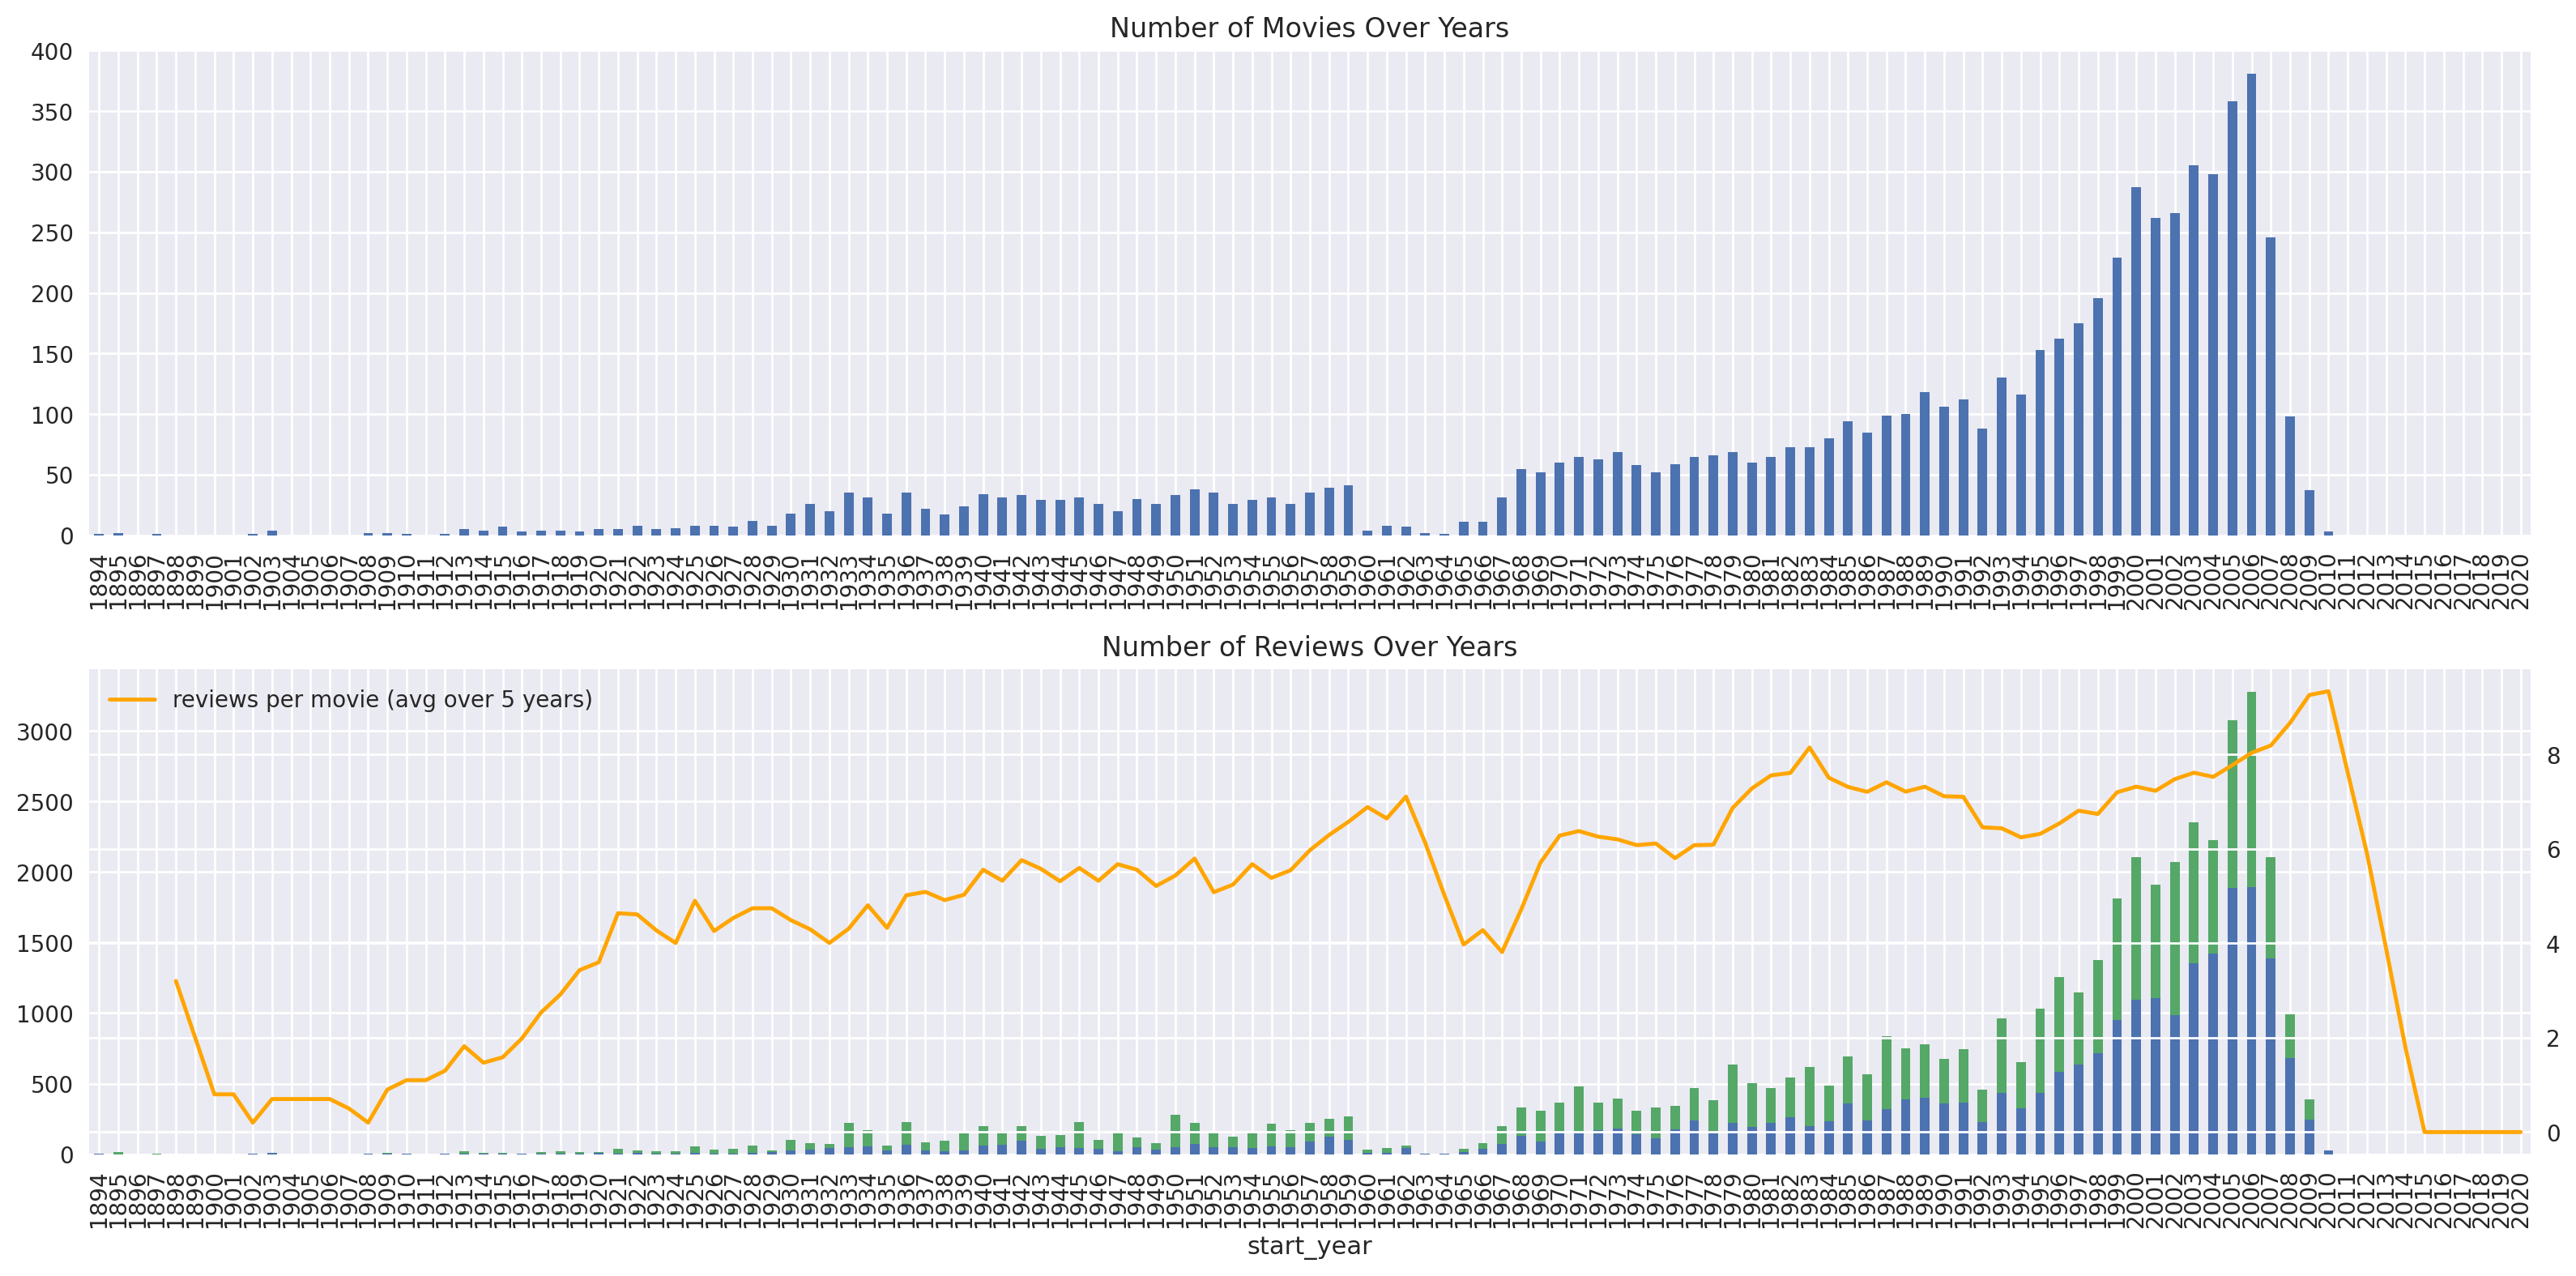

In [8]:
fig, axs = plt.subplots(2,
 1, figsize=(16, 8))

ax = axs[0]


dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Number of Movies Over Years')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='reviews per movie (avg over 5 years)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Number of Reviews Over Years')

fig.tight_layout()

Let's check the distribution of number of reviews per movie with the exact counting and KDE (just to learn how it may differ from the exact counting)

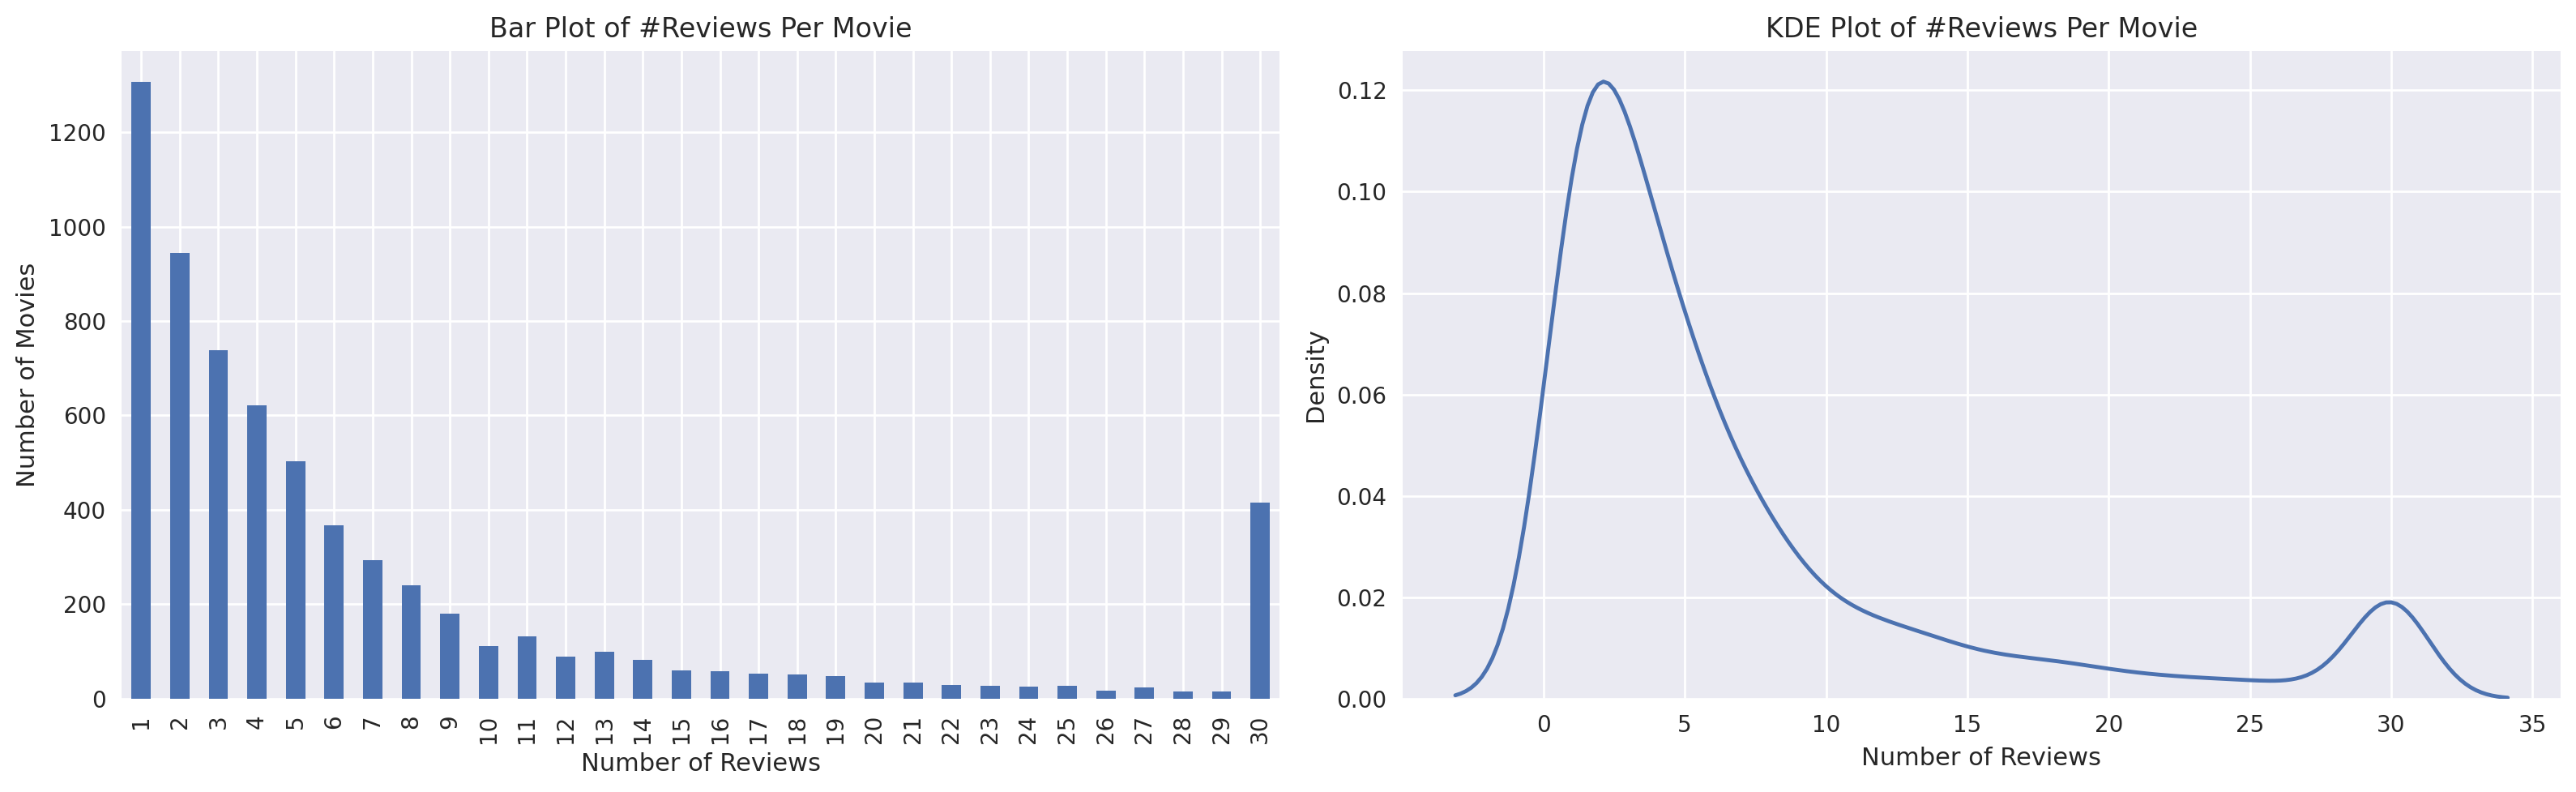

In [9]:

fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]

dft = (
    df_reviews.groupby('tconst')['review']
    .count()
    .value_counts()
    .sort_index()
)

dft.plot.bar(ax=ax)

ax.set_title('Bar Plot of #Reviews Per Movie')
ax.set_xlabel('Number of Reviews')
ax.set_ylabel('Number of Movies')

ax = axs[1]

dft = df_reviews.groupby('tconst')['review'].count()

sns.kdeplot(dft, ax=ax)

ax.set_title('KDE Plot of #Reviews Per Movie')
ax.set_xlabel('Number of Reviews')
ax.set_ylabel('Density')

fig.tight_layout()

EDA Observation: Reviews per Movie

The number of reviews per movie is strongly right-skewed. Most movies have only a small number of reviews, particularly between one and five, while considerably fewer movies have large numbers of reviews. There is also a noticeable group of movies with 30 reviews, which appears to be the upper limit represented in this prepared dataset.

Therefore, the reviews are not distributed evenly across movies. However, this does not by itself indicate whether the positive and negative target classes are imbalanced, so the distribution of the `pos` target must be examined separately.

In [10]:
df_reviews['pos'].value_counts()

0    23715
1    23616
Name: pos, dtype: int64

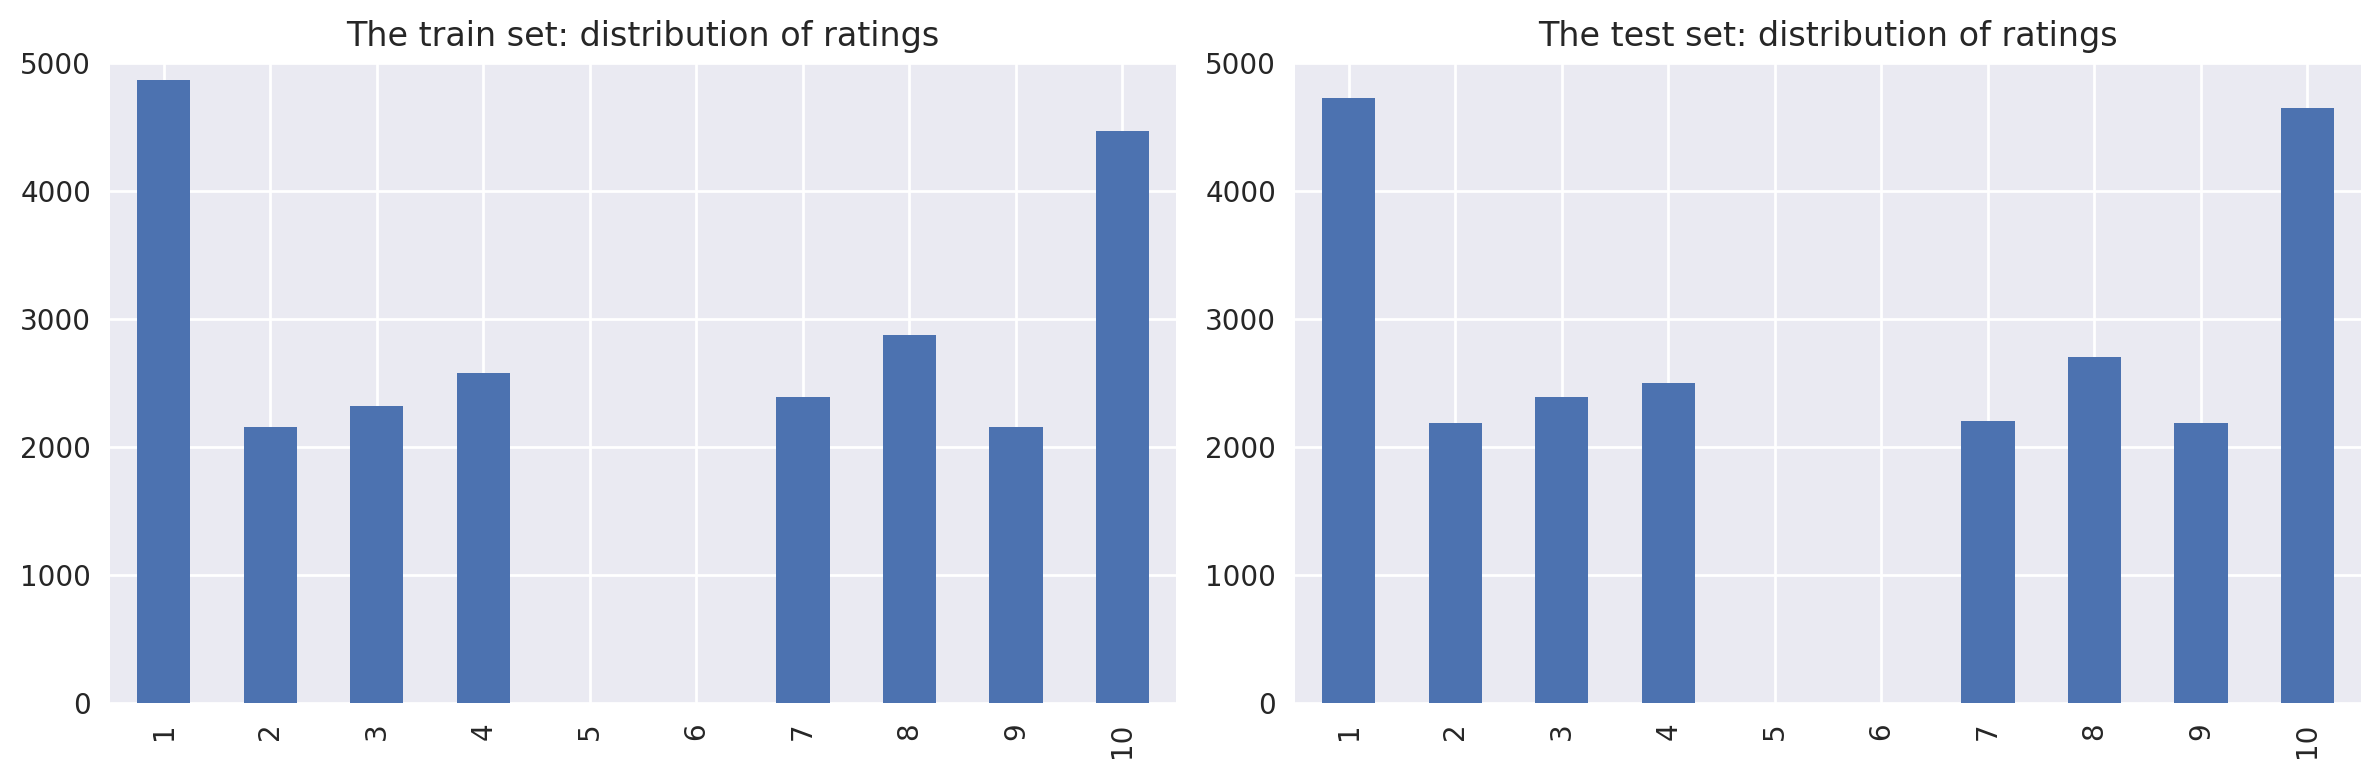

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The train set: distribution of ratings')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The test set: distribution of ratings')

fig.tight_layout()

EDA Observation: Rating Distribution

The training and test datasets have very similar rating distributions. Ratings 1 and 10 are the most common, while ratings 5 and 6 are absent because the dataset separates clearly negative reviews from clearly positive reviews.

The similar distributions indicate that the provided training and test sets are representative of one another. This reduces the risk that model performance will be distorted by a major difference in rating composition between the two datasets.

Distribution of negative and positive reviews over the years for two parts of the dataset

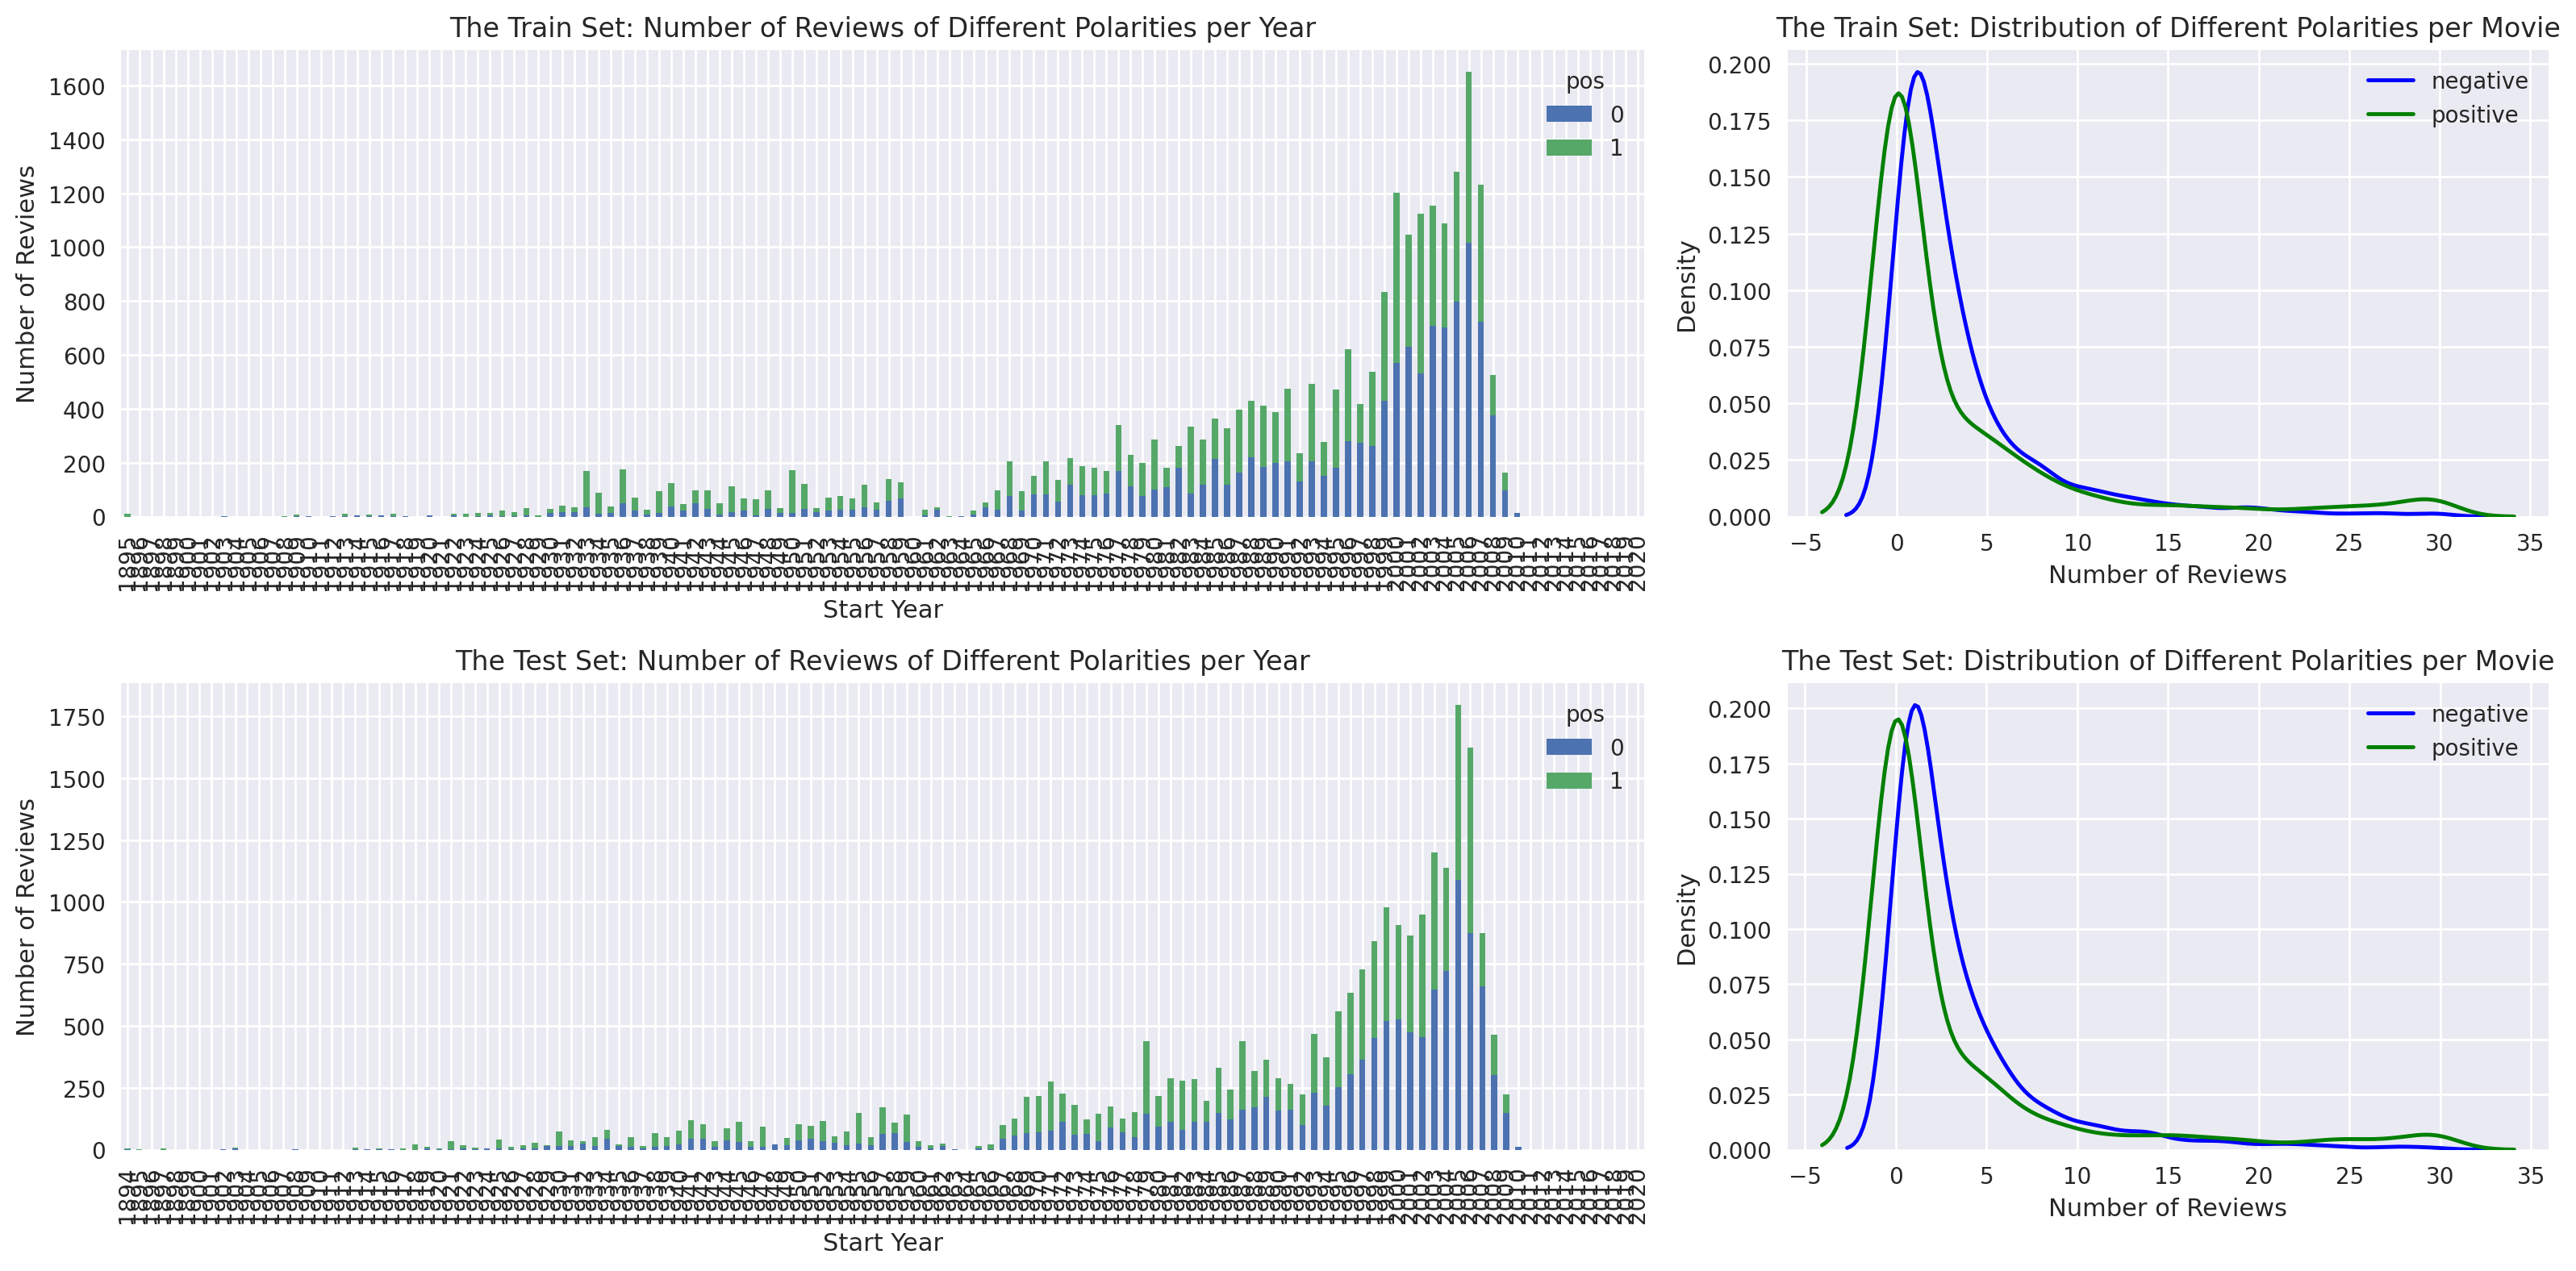

In [12]:
fig, axs = plt.subplots(
    2,
    2,
    figsize=(16, 8),
    gridspec_kw={
        'width_ratios': (2, 1),
        'height_ratios': (1, 1)
    }
)

# Training set: review polarity counts by year
ax = axs[0, 0]

dft = (
    df_reviews.query('ds_part == "train"')
    .groupby(['start_year', 'pos'])['pos']
    .count()
    .unstack()
)

dft.index = dft.index.astype('int')

dft = dft.reindex(
    index=np.arange(
        dft.index.min(),
        max(dft.index.max(), 2020) + 1
    )
).fillna(0)

dft.plot(
    kind='bar',
    stacked=True,
    ax=ax
)

ax.set_title(
    'The Train Set: Number of Reviews of Different Polarities per Year'
)
ax.set_xlabel('Start Year')
ax.set_ylabel('Number of Reviews')

# Training set: polarity distribution per movie
ax = axs[0, 1]

dft = (
    df_reviews.query('ds_part == "train"')
    .groupby(['tconst', 'pos'])['pos']
    .count()
    .unstack()
    .fillna(0)
)

sns.kdeplot(
    dft[0],
    color='blue',
    label='negative',
    ax=ax
)

sns.kdeplot(
    dft[1],
    color='green',
    label='positive',
    ax=ax
)

ax.legend()
ax.set_title(
    'The Train Set: Distribution of Different Polarities per Movie'
)
ax.set_xlabel('Number of Reviews')
ax.set_ylabel('Density')

# Test set: review polarity counts by year
ax = axs[1, 0]

dft = (
    df_reviews.query('ds_part == "test"')
    .groupby(['start_year', 'pos'])['pos']
    .count()
    .unstack()
)

dft.index = dft.index.astype('int')

dft = dft.reindex(
    index=np.arange(
        dft.index.min(),
        max(dft.index.max(), 2020) + 1
    )
).fillna(0)

dft.plot(
    kind='bar',
    stacked=True,
    ax=ax
)

ax.set_title(
    'The Test Set: Number of Reviews of Different Polarities per Year'
)
ax.set_xlabel('Start Year')
ax.set_ylabel('Number of Reviews')

# Test set: polarity distribution per movie
ax = axs[1, 1]

dft = (
    df_reviews.query('ds_part == "test"')
    .groupby(['tconst', 'pos'])['pos']
    .count()
    .unstack()
    .fillna(0)
)

sns.kdeplot(
    dft[0],
    color='blue',
    label='negative',
    ax=ax
)

sns.kdeplot(
    dft[1],
    color='green',
    label='positive',
    ax=ax
)

ax.legend()
ax.set_title(
    'The Test Set: Distribution of Different Polarities per Movie'
)
ax.set_xlabel('Number of Reviews')
ax.set_ylabel('Density')

fig.tight_layout()

EDA Conclusion:

The dataset contains 47,331 movie reviews. The target classes are nearly perfectly balanced: there are 23,715 negative reviews and 23,616 positive reviews, a difference of only 99 observations. Each class represents approximately 50% of the dataset, so class imbalance is not a concern and no resampling or class-weight adjustment is required.

The training and test portions also have similar rating and polarity distributions. Positive and negative reviews occur in comparable proportions across both dataset partitions and across most years. This indicates that the supplied test set is reasonably representative of the training data.

Most movies have only a few reviews, while a smaller number have many reviews. Reviews are also concentrated among movies released in more recent decades. These characteristics describe the composition of the dataset but do not create a meaningful imbalance in the prediction target.

Based on this analysis, the supplied `ds_part` division can be retained, and F1 score will be used as the primary model-evaluation metric because the project requires a test F1 score of at least 0.85.

## Evaluation Procedure

Composing an evaluation routine which can be used for all models in this project

In [13]:
import sklearn.metrics as metrics

def evaluate_model(model, train_features, train_target, test_features, test_target):
    
    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        
        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # PRC
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # F1 Score
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'F1 Score') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'ROC Curve')
        
        # PRC
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)
    
    return

## Normalization

We assume all models below accepts texts in lowercase and without any digits, punctuations marks etc.

In [14]:
import re


def normalize_text(text):
    """
    Converts text to lowercase, removes digits and punctuation,
    and eliminates extra spaces.
    """
    text = text.lower()
    text = re.sub(r"[^a-zA-Z']", " ", text)
    text = " ".join(text.split())

    return text


# Normalize every review
df_reviews['review_norm'] = (
    df_reviews['review']
    .fillna('')
    .apply(normalize_text)
)

# Compare the original and normalized reviews
display(
    df_reviews[['review', 'review_norm']].head()
)

,review,review_norm
0,The pakage implies that Warren Beatty and Gold...,the pakage implies that warren beatty and gold...
1,How the hell did they get this made?! Presenti...,how the hell did they get this made presenting...
2,There is no real story the film seems more lik...,there is no real story the film seems more lik...
3,Um .... a serious film about troubled teens in...,um a serious film about troubled teens in sing...
4,I'm totally agree with GarryJohal from Singapo...,i'm totally agree with garryjohal from singapo...


<div class="alert alert-success">
<b>Reviewer's comment v1:</b>

Great normalization function. You correctly strip digits and punctuation, convert to lowercase, and collapse extra whitespace. Applying it across the full dataset before the train/test split — and then fitting TF-IDF only on the training set — ensures no data leakage. Well done.
</div>

## Train / Test Split

Luckily, the whole dataset is already divided into train/test one parts. The corresponding flag is 'ds_part'.

In [15]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)

(23796, 18)
(23535, 18)


## Working with models

### Model 0 - Constant

In [16]:
from sklearn.dummy import DummyClassifier

In [17]:
# Create simple placeholder features for the constant baseline

train_features_0 = np.zeros(
    (len(df_reviews_train), 1)
)

test_features_0 = np.zeros(
    (len(df_reviews_test), 1)
)

print("Training feature shape:", train_features_0.shape)
print("Test feature shape:", test_features_0.shape)

Training feature shape: (23796, 1)
Test feature shape: (23535, 1)


In [18]:
# Train a constant baseline classifier

model_0 = DummyClassifier(
    strategy='most_frequent'
)

model_0.fit(
    train_features_0,
    train_target
)

print("Model 0 training complete.")

Model 0 training complete.


          train  test
Accuracy    0.5   0.5
F1          0.0   0.0
APS         0.5   0.5
ROC AUC     0.5   0.5


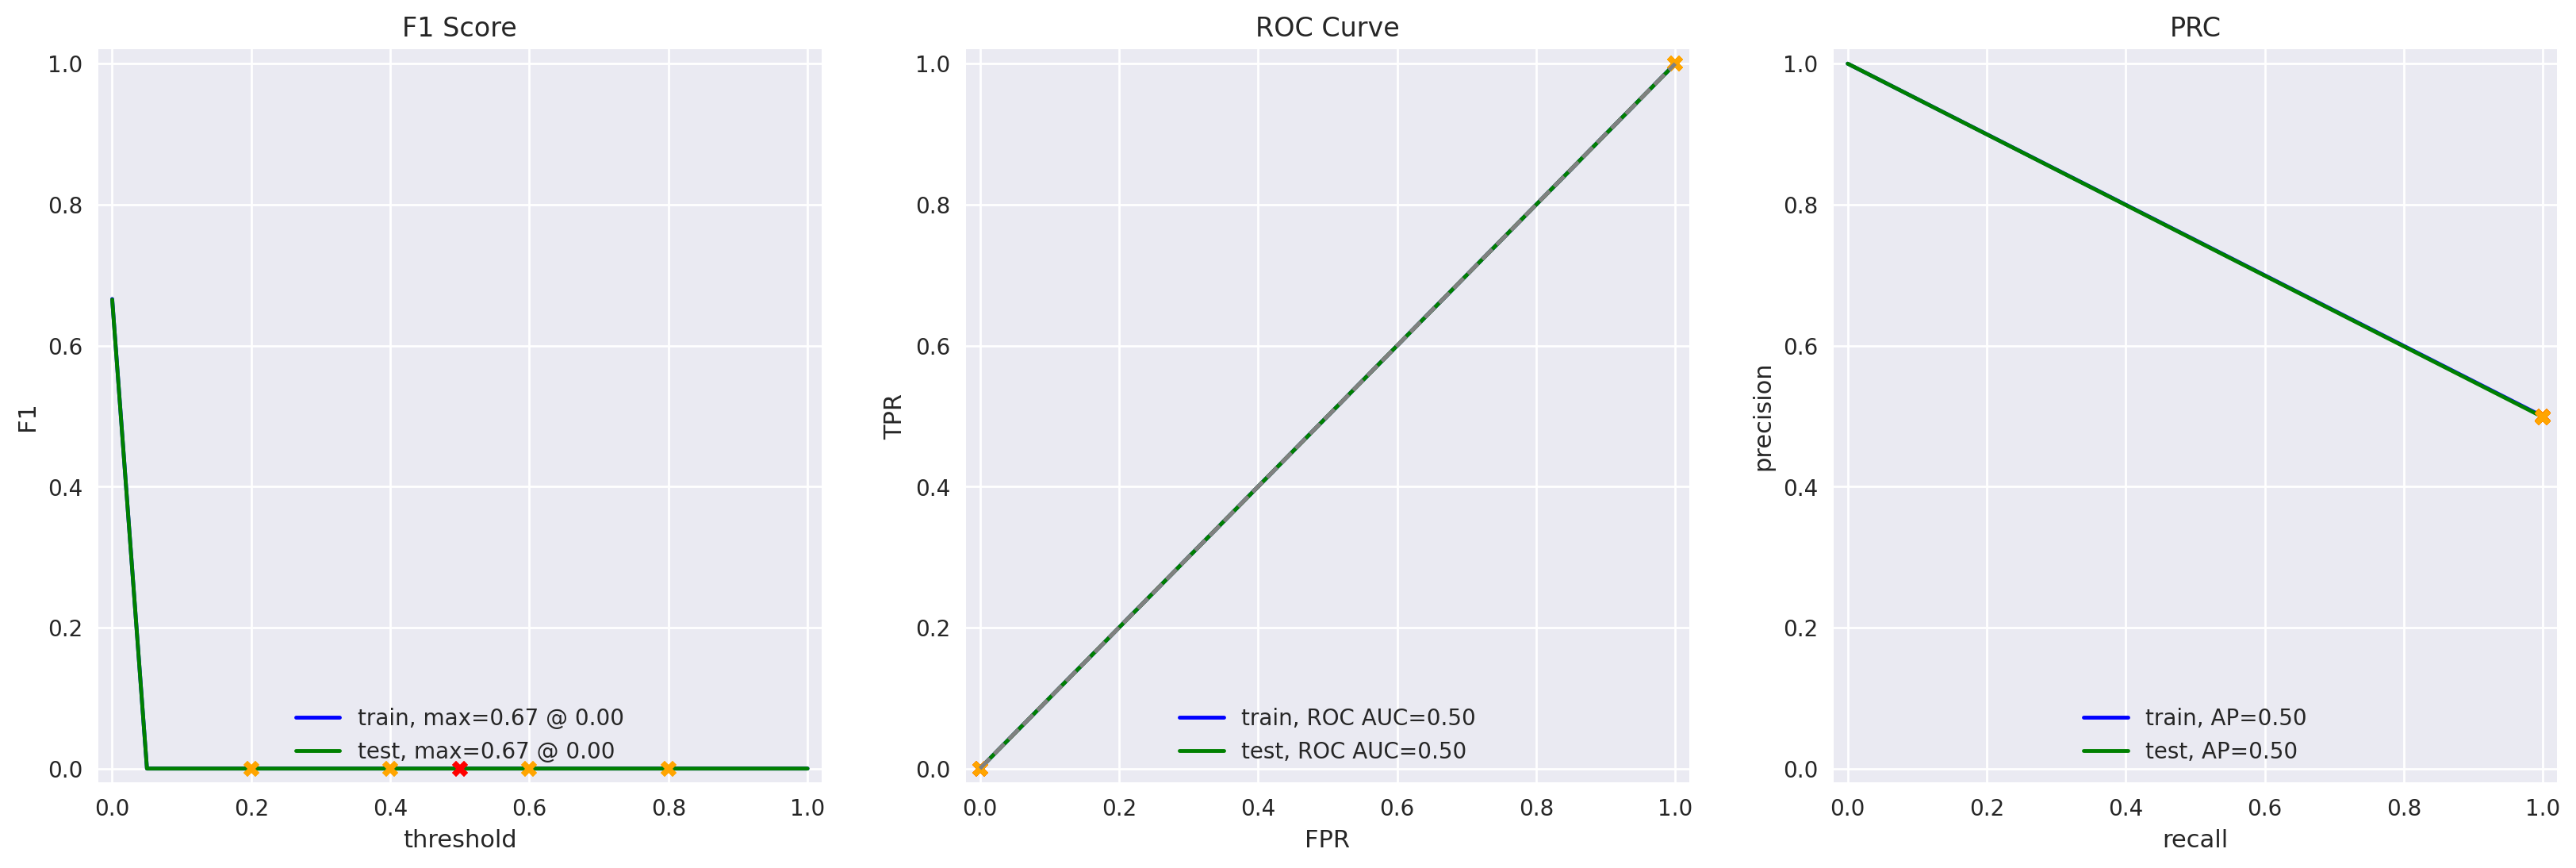

In [19]:
# Evaluate the constant baseline model

evaluate_model(
    model_0,
    train_features_0,
    train_target,
    test_features_0,
    test_target
)

### Model 1 - NLTK, TF-IDF and LR

TF-IDF

In [20]:
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from nltk.corpus import stopwords

In [21]:
# Download and prepare the English stop-word list
nltk.download('stopwords', quiet=True)

stop_words = stopwords.words('english')

# Create the TF-IDF vectorizer
tfidf_vectorizer_1 = TfidfVectorizer(
    stop_words=stop_words,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=100000,
    sublinear_tf=True
)

# Fit only on the training reviews
train_features_1 = tfidf_vectorizer_1.fit_transform(
    df_reviews_train['review_norm']
)

# Transform the test reviews using the fitted vectorizer
test_features_1 = tfidf_vectorizer_1.transform(
    df_reviews_test['review_norm']
)

print("Training TF-IDF shape:", train_features_1.shape)
print("Test TF-IDF shape:", test_features_1.shape)

Training TF-IDF shape: (23796, 100000)
Test TF-IDF shape: (23535, 100000)


<div class="alert alert-success">
<b>Reviewer's comment v1:</b>

Excellent TF-IDF configuration. Using stop words, bigrams ('ngram_range=(1, 2)'), 'min_df=2', 'max_df=0.95', and 'sublinear_tf=True' together is a well-considered combination. Fitting the vectorizer only on the training set and applying 'transform' on the test set is exactly correct — no data leakage.
</div>

In [22]:
# Train Logistic Regression on the TF-IDF features

model_1 = LogisticRegression(
    C=5.0,
    max_iter=1000,
    solver='liblinear',
    random_state=42
)

model_1.fit(
    train_features_1,
    train_target
)

print("Model 1 training complete.")

Model 1 training complete.


          train  test
Accuracy   0.99  0.90
F1         0.99  0.89
APS        1.00  0.96
ROC AUC    1.00  0.96


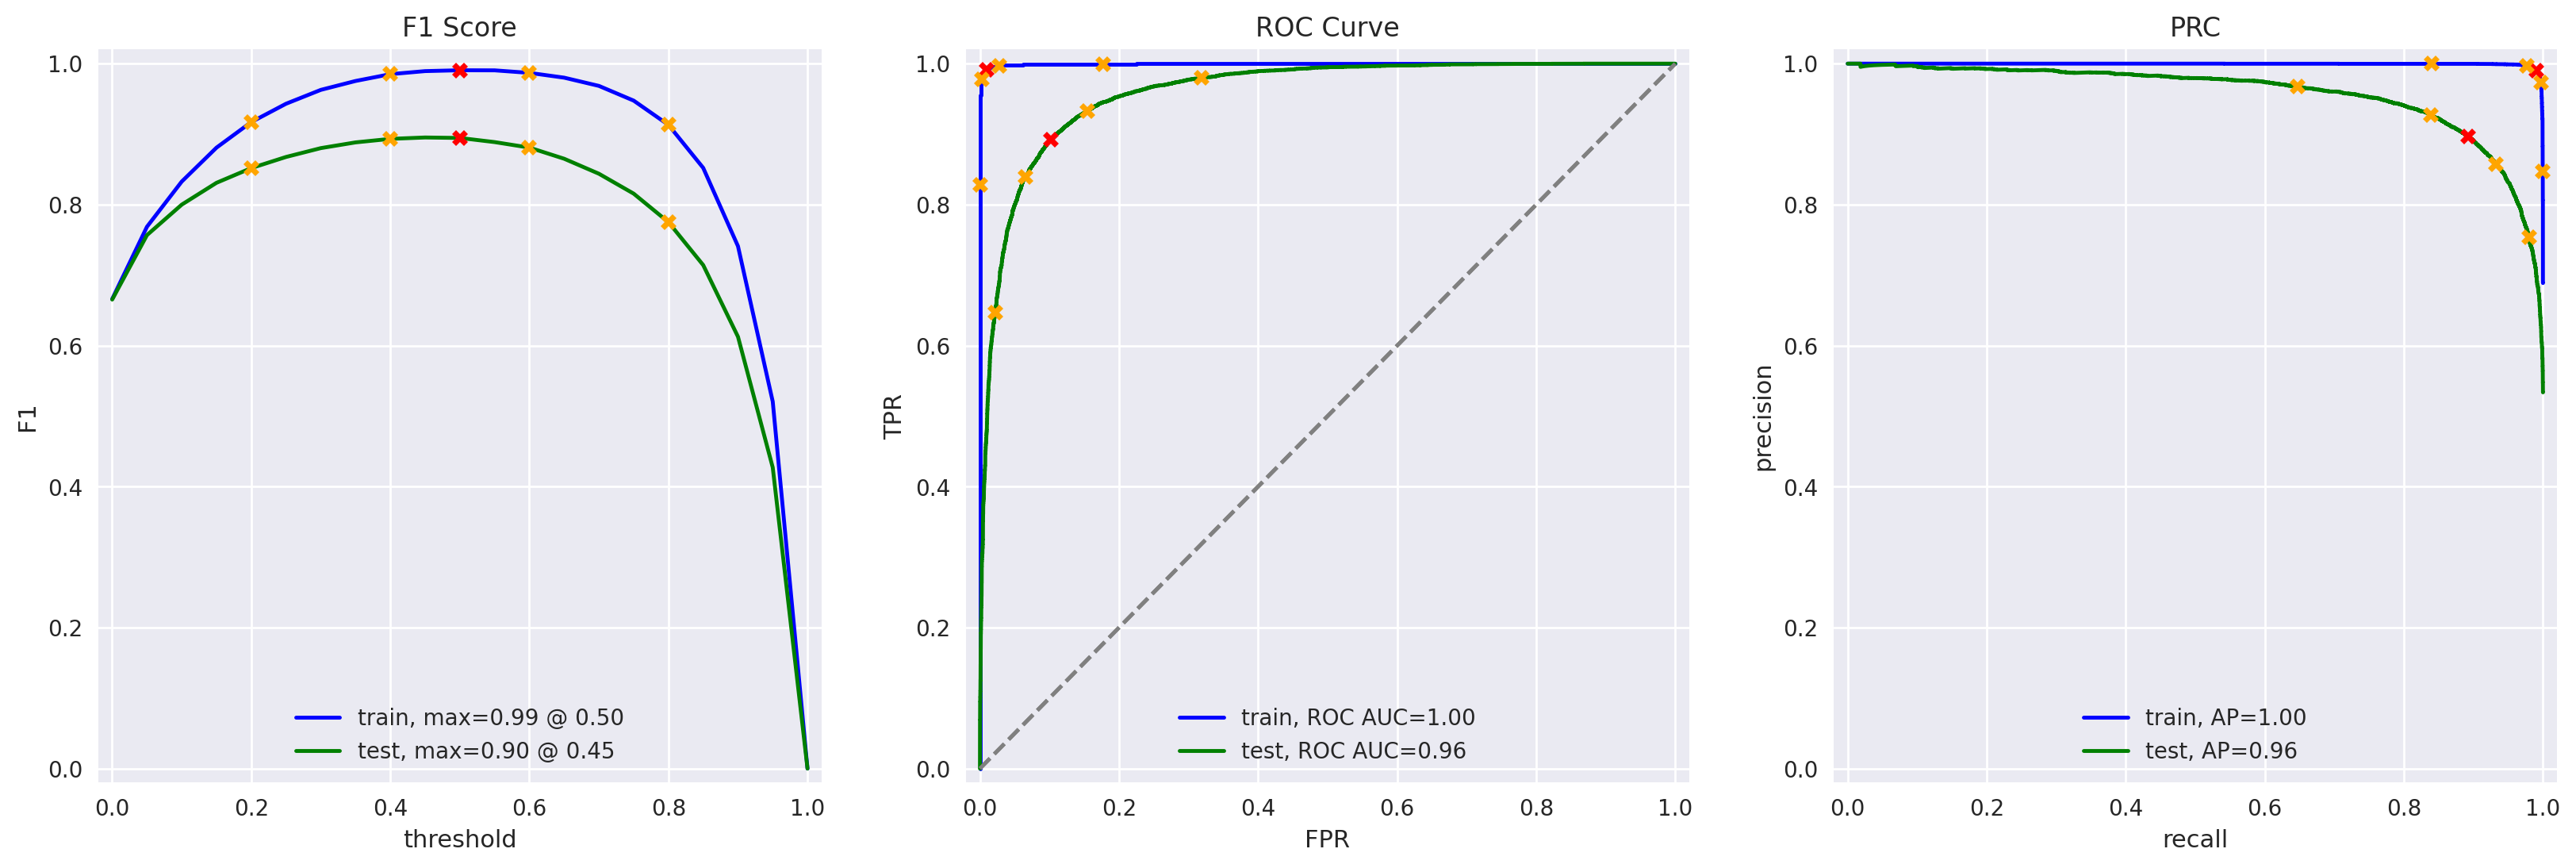

In [23]:
evaluate_model(model_1, train_features_1, train_target, test_features_1, test_target)

<div class="alert alert-success">
<b>Reviewer's comment v1:</b>

Model 1 achieves a test F1 of 0.89 and test accuracy of 0.90, clearly surpassing the required threshold of 0.85. The train/test gap indicates mild overfitting, which is expected with a high-dimensional TF-IDF space. The overall result is strong and the vectorizer was correctly fitted only on the training data.
</div>

### Model 3 - spaCy, TF-IDF and LR

In [24]:
import spacy

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

In [25]:
def text_preprocessing_3(text):
    """
    Lemmatizes normalized text using spaCy.
    """
    doc = nlp(text)

    tokens = [
        token.lemma_
        for token in doc
        if not token.is_space
    ]

    return ' '.join(tokens)

In [26]:
def lemmatize_texts_spacy(texts, batch_size=256):
    """
    Lemmatizes a collection of texts efficiently using spaCy's pipe.
    """
    lemmatized_texts = []

    documents = nlp.pipe(
        texts,
        batch_size=batch_size
    )

    for doc in tqdm(
        documents,
        total=len(texts),
        desc='Lemmatizing reviews'
    ):
        lemmas = [
            token.lemma_
            for token in doc
            if not token.is_space
        ]

        lemmatized_texts.append(
            ' '.join(lemmas)
        )

    return lemmatized_texts


# Lemmatize the training and test reviews
train_texts_3 = lemmatize_texts_spacy(
    df_reviews_train['review_norm'].tolist()
)

test_texts_3 = lemmatize_texts_spacy(
    df_reviews_test['review_norm'].tolist()
)

print("Lemmatized training reviews:", len(train_texts_3))
print("Lemmatized test reviews:", len(test_texts_3))

Lemmatizing reviews:   0%|          | 0/23796 [00:00<?, ?it/s]

Lemmatizing reviews:   0%|          | 0/23535 [00:00<?, ?it/s]

Lemmatized training reviews: 23796
Lemmatized test reviews: 23535


In [27]:
# Create TF-IDF features from the spaCy-lemmatized reviews

tfidf_vectorizer_3 = TfidfVectorizer(
    stop_words=stop_words,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=100000,
    sublinear_tf=True
)

train_features_3 = tfidf_vectorizer_3.fit_transform(
    train_texts_3
)

test_features_3 = tfidf_vectorizer_3.transform(
    test_texts_3
)

print("Model 3 training feature shape:", train_features_3.shape)
print("Model 3 test feature shape:", test_features_3.shape)

Model 3 training feature shape: (23796, 100000)
Model 3 test feature shape: (23535, 100000)


In [28]:
# Train Logistic Regression using the spaCy TF-IDF features

model_3 = LogisticRegression(
    C=5.0,
    max_iter=1000,
    solver='liblinear',
    random_state=42
)

model_3.fit(
    train_features_3,
    train_target
)

print("Model 3 training complete.")

Model 3 training complete.


          train  test
Accuracy   0.99  0.89
F1         0.99  0.89
APS        1.00  0.96
ROC AUC    1.00  0.96


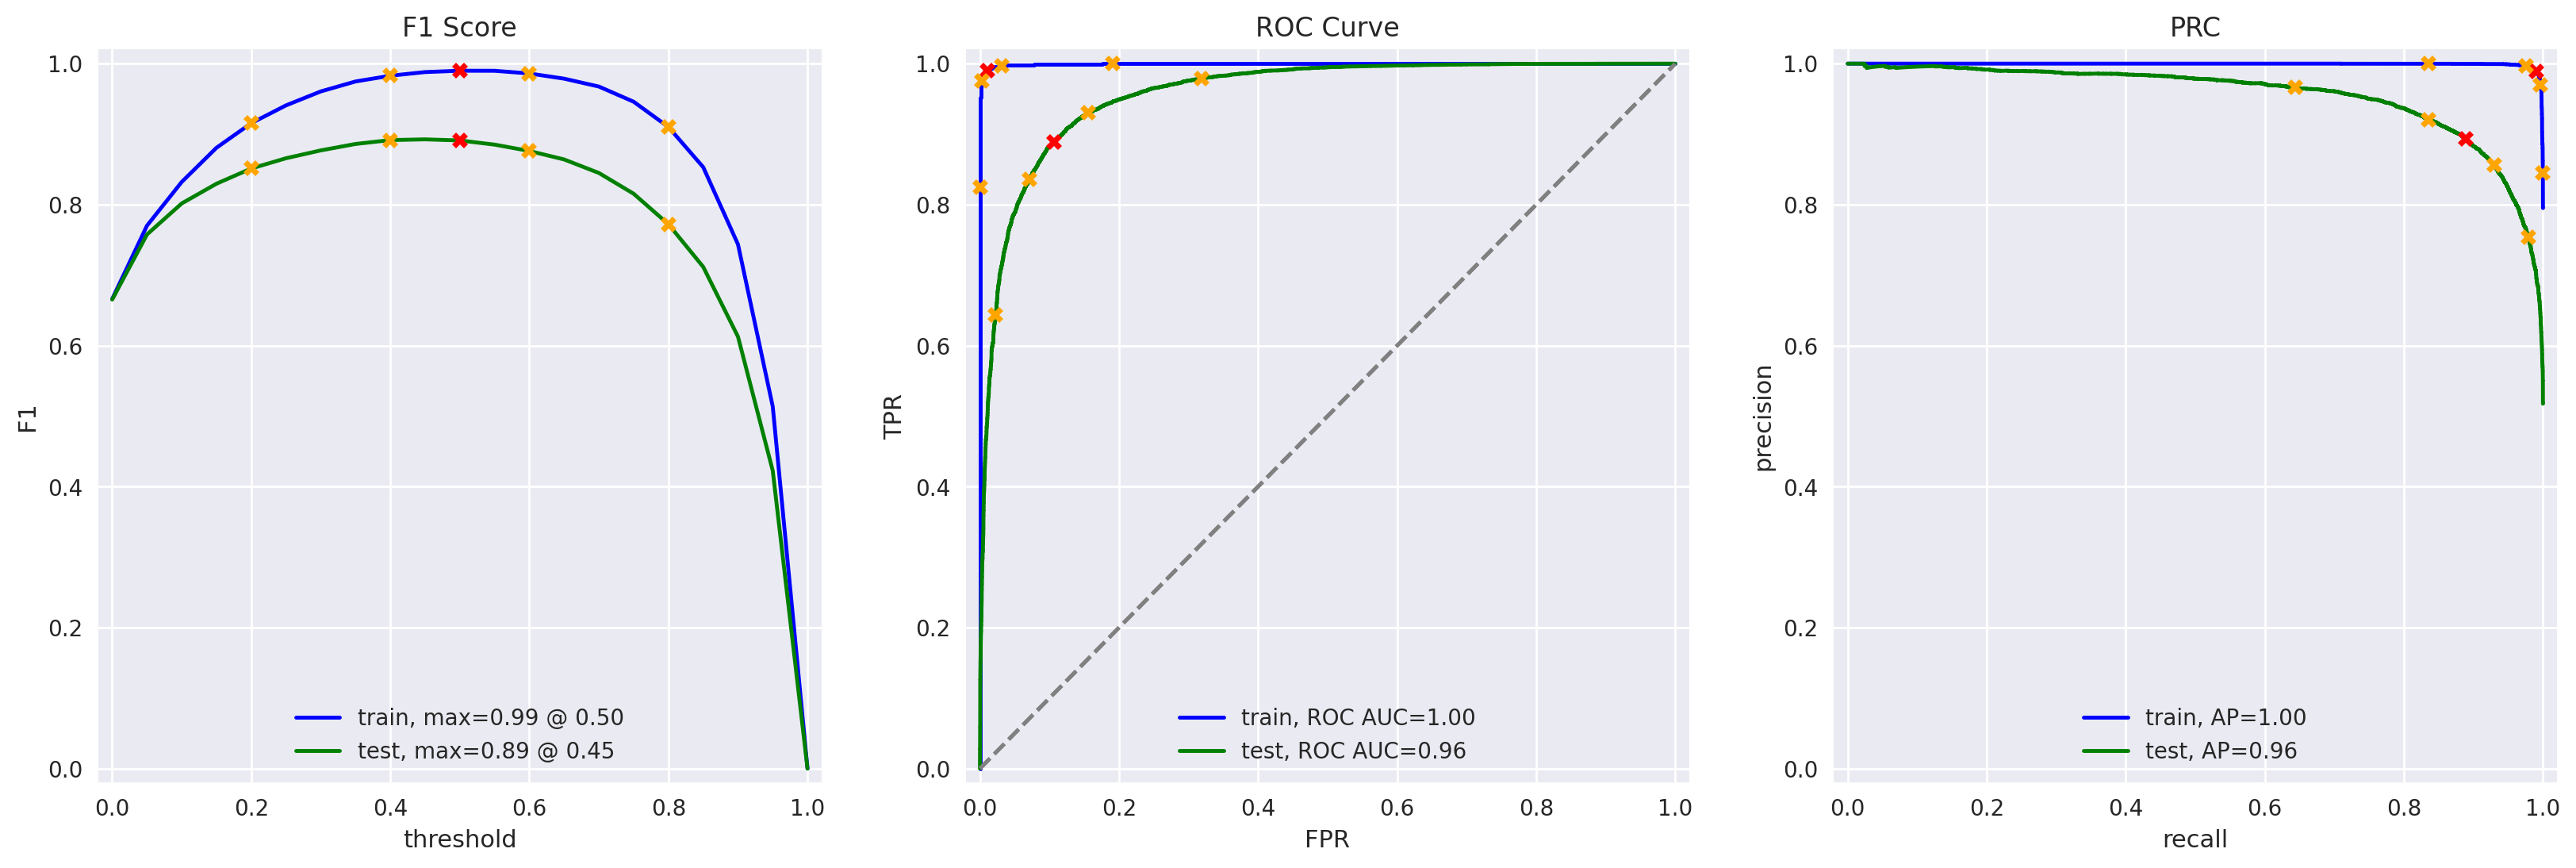

In [29]:
# Evaluate Model 3

evaluate_model(
    model_3,
    train_features_3,
    train_target,
    test_features_3,
    test_target
)

<div class="alert alert-success">
<b>Reviewer's comment v1:</b>

Model 3 matches Model 1's test F1 of 0.89. The spaCy lemmatization pipeline is implemented correctly — 'fit_transform' on training texts and 'transform' on test texts. Your observation that lemmatization did not meaningfully improve over the simpler approach is accurate and reflects good analytical thinking.
</div>

### Model 4 - spaCy, TF-IDF and LGBMClassifier

In [30]:
from lightgbm import LGBMClassifier

In [31]:
# Train LightGBM using the spaCy TF-IDF features

model_4 = LGBMClassifier(
    objective='binary',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

model_4.fit(
    train_features_3,
    train_target
)

print("Model 4 training complete.")

Model 4 training complete.


          train  test
Accuracy   0.97  0.88
F1         0.97  0.88
APS        1.00  0.95
ROC AUC    1.00  0.95


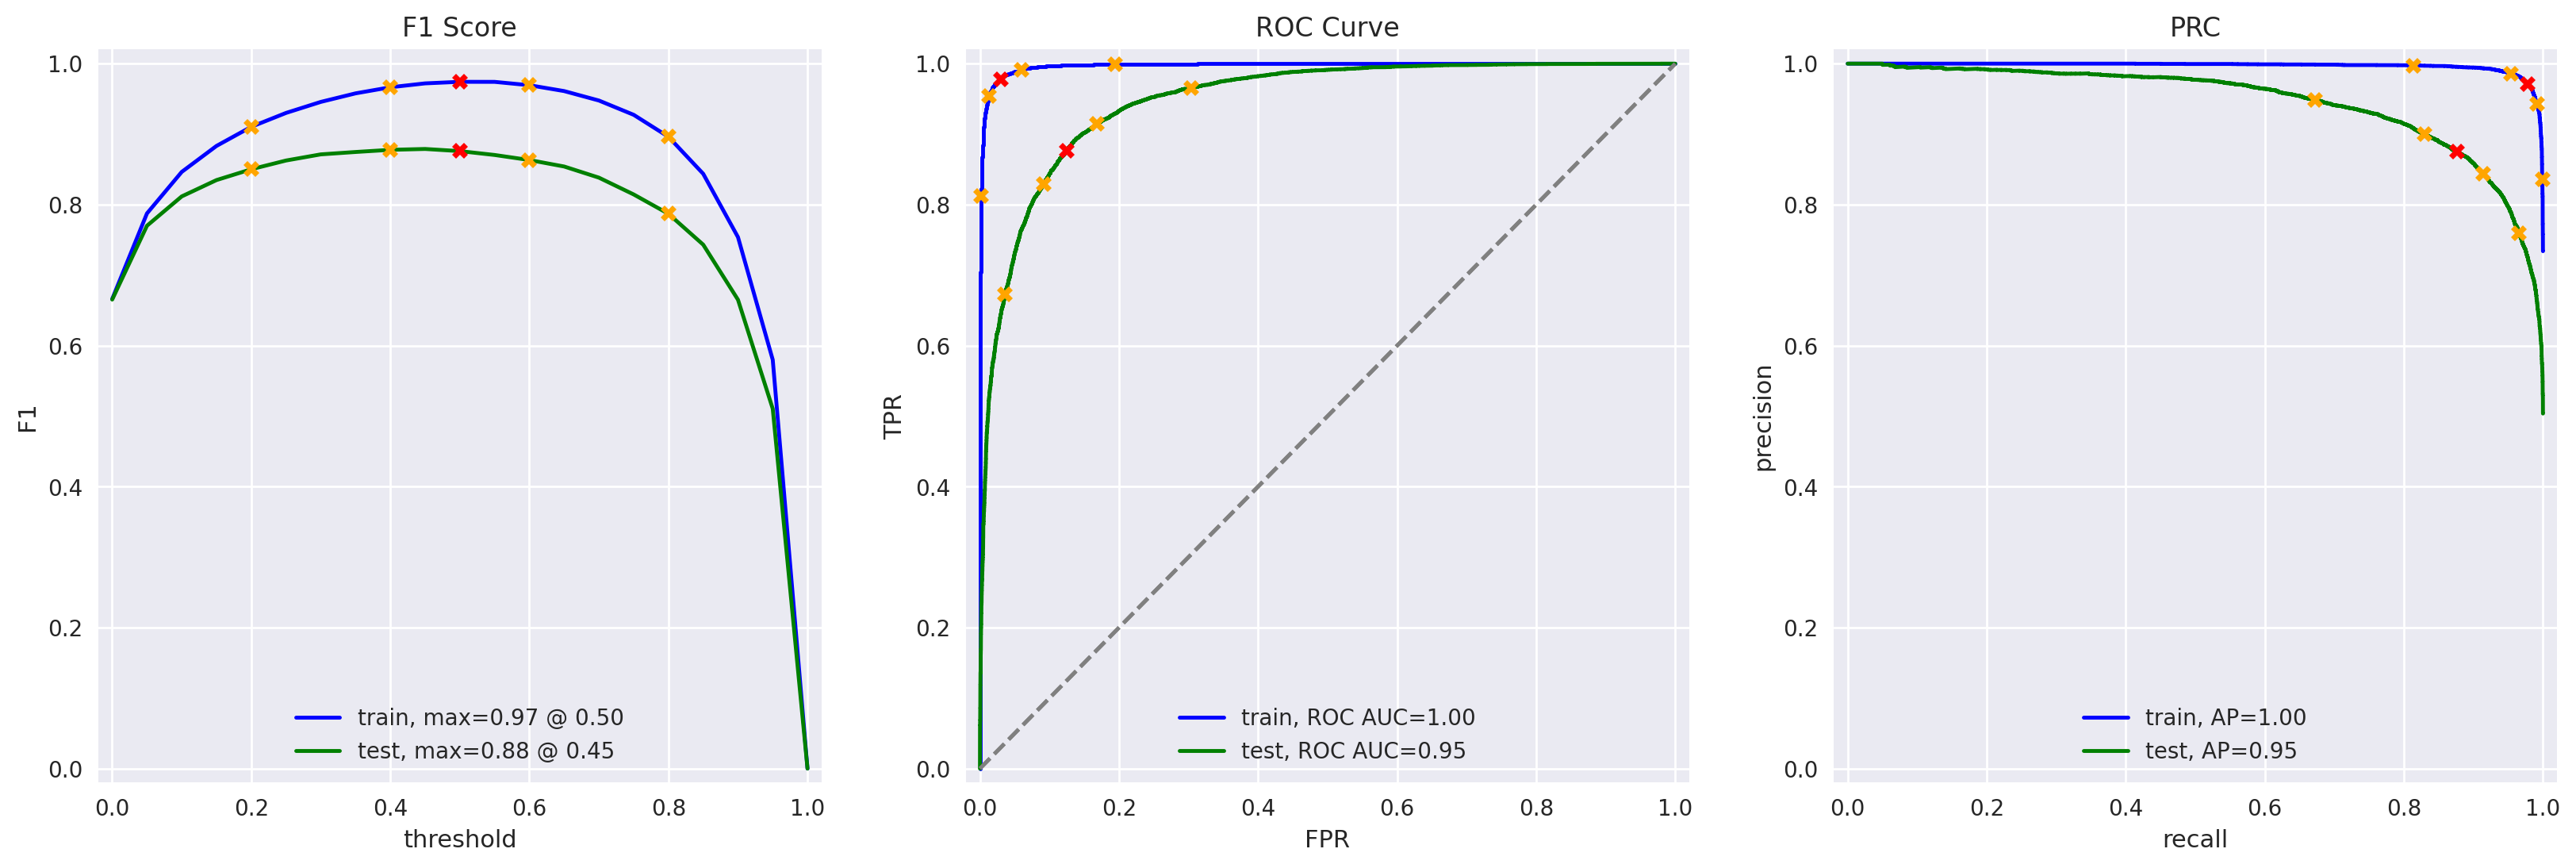

In [32]:
# Evaluate Model 4

evaluate_model(
    model_4,
    train_features_3,
    train_target,
    test_features_3,
    test_target
)

<div class="alert alert-success">
<b>Reviewer's comment v1:</b>

Model 4 (LightGBM) achieves a test F1 of 0.88, also above the 0.85 threshold. The hyperparameters are reasonable and the model correctly reuses the spaCy TF-IDF features already computed for Model 3. Good work.
</div>

Interim Model Comparison:

Three substantive modeling approaches were tested in addition to the constant baseline:

- Model 1 — TF-IDF and Logistic Regression:** test F1 = 0.89 and test accuracy = 0.90.
- Model 3 — spaCy, TF-IDF, and Logistic Regression:** test F1 = 0.89 and test accuracy = 0.89.
- Model 4 — spaCy, TF-IDF, and LightGBM:** test F1 = 0.88 and test accuracy = 0.88.

All three trained text-classification approaches exceeded the required test F1 score of 0.85. Model 1 provided the best combination of predictive performance and computational efficiency. Model 3 required the additional expense of spaCy lemmatization without improving F1, while Model 4 was slightly less accurate despite requiring a more complex gradient-boosting model.

Therefore, Model 1 is currently the preferred model.

###  Model 9 - BERT

BERT Exclusion:

BERT was not included in the final model comparison because it is optional for this project and requires considerably more computational power than the available CPU environment can provide. Processing the complete dataset with BERT could require several hours and is generally better suited to GPU execution.

The project requirement was satisfied using TF-IDF with Logistic Regression and LightGBM. These models exceeded the required test F1 score of 0.85, with the best test F1 reaching 0.89.

## My Reviews

In [33]:

# Create original reviews for testing the trained models

my_reviews = pd.DataFrame(
    [
        "I did not like it at all. It was not my kind of movie.",
        "I was bored and fell asleep in the middle of the movie.",
        "I was fascinated by the movie and loved every minute.",
        "The actors looked uninterested, and the story felt like a soulless cash grab.",
        "The reboot was surprisingly good. The writers clearly cared about the source material.",
        "The movie had some flaws, but overall it was an enjoyable and worthwhile film.",
        "What a terrible attempt at comedy. Not a single joke landed.",
        "This was an intelligent and exciting drama with excellent performances."
    ],
    columns=['review']
)

# Apply the same normalization used for the main dataset
my_reviews['review_norm'] = (
    my_reviews['review']
    .apply(normalize_text)
)

display(my_reviews)

,review,review_norm
0,I did not like it at all. It was not my kind o...,i did not like it at all it was not my kind of...
1,I was bored and fell asleep in the middle of t...,i was bored and fell asleep in the middle of t...
2,I was fascinated by the movie and loved every ...,i was fascinated by the movie and loved every ...
3,"The actors looked uninterested, and the story ...",the actors looked uninterested and the story f...
4,The reboot was surprisingly good. The writers ...,the reboot was surprisingly good the writers c...
5,"The movie had some flaws, but overall it was a...",the movie had some flaws but overall it was an...
6,What a terrible attempt at comedy. Not a singl...,what a terrible attempt at comedy not a single...
7,This was an intelligent and exciting drama wit...,this was an intelligent and exciting drama wit...


### Model 2

<div class="alert alert-warning">
<b>Reviewer's comment v1:</b>

Minor naming inconsistency: this section header reads 'Model 2' but the code below applies 'tfidf_vectorizer_1' and 'model_1', and all surrounding sections refer to Model 1. The code itself is correct — only the heading label needs to be updated to 'Model 1' for clarity.
</div>

In [34]:
# Classify the custom reviews with Model 1

my_features_1 = tfidf_vectorizer_1.transform(
    my_reviews['review_norm']
)

my_reviews['model_1_probability'] = (
    model_1.predict_proba(my_features_1)[:, 1]
)

my_reviews['model_1_prediction'] = np.where(
    my_reviews['model_1_probability'] >= 0.5,
    'positive',
    'negative'
)

display(
    my_reviews[
        [
            'review',
            'model_1_probability',
            'model_1_prediction'
        ]
    ]
)

,review,model_1_probability,model_1_prediction
0,I did not like it at all. It was not my kind o...,0.183687,negative
1,I was bored and fell asleep in the middle of t...,0.025050,negative
2,I was fascinated by the movie and loved every ...,0.876309,positive
3,"The actors looked uninterested, and the story ...",0.079230,negative
4,The reboot was surprisingly good. The writers ...,0.575747,positive
5,"The movie had some flaws, but overall it was a...",0.878916,positive
6,What a terrible attempt at comedy. Not a singl...,0.008990,negative
7,This was an intelligent and exciting drama wit...,0.996753,positive


### Model 3

In [35]:
# Lemmatize the custom reviews for Model 3

my_texts_3 = [
    text_preprocessing_3(text)
    for text in my_reviews['review_norm']
]

# Transform the reviews using Model 3's TF-IDF vectorizer
my_features_3 = tfidf_vectorizer_3.transform(
    my_texts_3
)

# Generate Model 3 predictions
my_reviews['model_3_probability'] = (
    model_3.predict_proba(my_features_3)[:, 1]
)

my_reviews['model_3_prediction'] = np.where(
    my_reviews['model_3_probability'] >= 0.5,
    'positive',
    'negative'
)

display(
    my_reviews[
        [
            'review',
            'model_3_probability',
            'model_3_prediction'
        ]
    ]
)

,review,model_3_probability,model_3_prediction
0,I did not like it at all. It was not my kind o...,0.165609,negative
1,I was bored and fell asleep in the middle of t...,0.020350,negative
2,I was fascinated by the movie and loved every ...,0.706535,positive
3,"The actors looked uninterested, and the story ...",0.129999,negative
4,The reboot was surprisingly good. The writers ...,0.579819,positive
5,"The movie had some flaws, but overall it was a...",0.911228,positive
6,What a terrible attempt at comedy. Not a singl...,0.006166,negative
7,This was an intelligent and exciting drama wit...,0.998044,positive


### Model 4

In [36]:
# Classify the custom reviews with Model 4

my_reviews['model_4_probability'] = (
    model_4.predict_proba(my_features_3)[:, 1]
)

my_reviews['model_4_prediction'] = np.where(
    my_reviews['model_4_probability'] >= 0.5,
    'positive',
    'negative'
)

display(
    my_reviews[
        [
            'review',
            'model_4_probability',
            'model_4_prediction'
        ]
    ]
)

,review,model_4_probability,model_4_prediction
0,I did not like it at all. It was not my kind o...,0.688176,positive
1,I was bored and fell asleep in the middle of t...,0.212454,negative
2,I was fascinated by the movie and loved every ...,0.632261,positive
3,"The actors looked uninterested, and the story ...",0.505497,positive
4,The reboot was surprisingly good. The writers ...,0.861126,positive
5,"The movie had some flaws, but overall it was a...",0.852736,positive
6,What a terrible attempt at comedy. Not a singl...,0.133536,negative
7,This was an intelligent and exciting drama wit...,0.964140,positive


### Custom Review Prediction Comparison

In [37]:
# Compare predictions from all three trained models

prediction_comparison = my_reviews[
    [
        'review',
        'model_1_probability',
        'model_1_prediction',
        'model_3_probability',
        'model_3_prediction',
        'model_4_probability',
        'model_4_prediction'
    ]
].copy()

probability_columns = [
    'model_1_probability',
    'model_3_probability',
    'model_4_probability'
]

prediction_comparison[probability_columns] = (
    prediction_comparison[probability_columns]
    .round(3)
)

prediction_comparison['all_models_agree'] = (
    (
        prediction_comparison['model_1_prediction']
        == prediction_comparison['model_3_prediction']
    )
    &
    (
        prediction_comparison['model_1_prediction']
        == prediction_comparison['model_4_prediction']
    )
)

display(prediction_comparison)

print(
    "Reviews with full model agreement:",
    prediction_comparison['all_models_agree'].sum(),
    "out of",
    len(prediction_comparison)
)

,review,model_1_probability,model_1_prediction,model_3_probability,model_3_prediction,model_4_probability,model_4_prediction,all_models_agree
0,I did not like it at all. It was not my kind o...,0.184,negative,0.166,negative,0.688,positive,False
1,I was bored and fell asleep in the middle of t...,0.025,negative,0.020,negative,0.212,negative,True
2,I was fascinated by the movie and loved every ...,0.876,positive,0.707,positive,0.632,positive,True
3,"The actors looked uninterested, and the story ...",0.079,negative,0.130,negative,0.505,positive,False
4,The reboot was surprisingly good. The writers ...,0.576,positive,0.580,positive,0.861,positive,True
5,"The movie had some flaws, but overall it was a...",0.879,positive,0.911,positive,0.853,positive,True
6,What a terrible attempt at comedy. Not a singl...,0.009,negative,0.006,negative,0.134,negative,True
7,This was an intelligent and exciting drama wit...,0.997,positive,0.998,positive,0.964,positive,True


Reviews with full model agreement: 6 out of 8


<div class="alert alert-success">
<b>Reviewer's comment v1:</b>

Excellent comparison table. Adding the 'all_models_agree' flag is a clean, informative touch. The subsequent analysis explaining why LightGBM misclassifies the negation-heavy short reviews — and why the Logistic Regression models handle bigrams like 'did not' more effectively — is well-argued and shows strong understanding of the models' behaviors.
</div>

## Conclusions

Model Performance Summary:

The dataset contained 47,331 reviews and had an almost perfectly balanced target distribution, so no class-balancing procedure was required.

The constant baseline model provided a weak reference point and demonstrated that simply predicting the most frequent class could not solve the sentiment-classification problem.

Three substantive text-classification approaches were then trained and tested:

- Model 1 — TF-IDF and Logistic Regression:** test F1 = 0.89, test accuracy = 0.90, test ROC AUC = 0.96, and test average precision = 0.96.
- Model 3 — spaCy, TF-IDF, and Logistic Regression:** test F1 = 0.89, test accuracy = 0.89, test ROC AUC = 0.96, and test average precision = 0.96.
- Model 4 — spaCy, TF-IDF, and LightGBM:** test F1 = 0.88, test accuracy = 0.88, test ROC AUC = 0.95, and test average precision = 0.95.

All three trained text models exceeded the required test F1 threshold of 0.85. Model 1 produced the best overall combination of test accuracy, F1 score, and computational efficiency.

<div class="alert alert-success">
<b>Reviewer's comment v1:</b>

Strong conclusions section. All required elements are present: the best model is identified, the required F1 threshold is confirmed as exceeded, model tradeoffs are discussed, and future improvement directions are outlined. This is well above the minimum standard for this project.
</div>

Custom Review Prediction Analysis:

The three models agreed on 6 of the 8 original reviews. They correctly agreed on clearly negative statements involving boredom, failed comedy, and dissatisfaction, as well as clearly positive statements involving fascination, strong writing, enjoyment, and excellent performances.

The models disagreed on two negative reviews:

1. For “I did not like it at all,” Models 1 and 3 predicted negative sentiment with positive probabilities of 0.184 and 0.166. Model 4 incorrectly predicted positive sentiment with a probability of 0.688.
2. For the review describing uninterested actors and a soulless story, Models 1 and 3 again predicted negative sentiment with probabilities of 0.079 and 0.130. Model 4 predicted positive sentiment with a probability of 0.505.

The second LightGBM disagreement was very close to the classification threshold, indicating uncertainty. The first disagreement may have occurred because the model placed too much importance on the word “like” without representing the surrounding negation as effectively as the TF-IDF Logistic Regression models.

The Logistic Regression models handled these short reviews more consistently. Their linear weighting of unigram and bigram TF-IDF features helped them recognize combinations such as “did not,” “not like,” and other strongly negative language. These results are consistent with their slightly better performance on the full test dataset.

Final Recommendation:

Model 1, which combines normalized review text, unigram and bigram TF-IDF features, and Logistic Regression, is the recommended solution for the Film Junky Union.

It achieved a test F1 score of 0.89, exceeding the required threshold of 0.85. It also achieved the highest test accuracy of 0.90 while requiring less preprocessing and training time than the spaCy and LightGBM alternatives. Adding spaCy lemmatization did not improve the F1 score, and LightGBM produced slightly weaker test results and more inconsistent predictions on the custom reviews.

The selected model can be used to automatically identify negative reviews and support the community's review-filtering and categorization system. Prediction probabilities can also be retained so that uncertain reviews near the 0.50 threshold can be flagged for manual review instead of being classified automatically.

Potential future improvements include threshold tuning, testing character-level TF-IDF features, performing hyperparameter optimization, expanding the collection of difficult examples involving negation or sarcasm, and evaluating transformer-based models when GPU resources are available.

Overall, the project objective was achieved: the text was cleaned and vectorized, multiple models were trained and tested, original reviews were classified, and the required F1 threshold was exceeded.

# Checklist

- [x]  Notebook was opened
- [ x]  The text data is loaded and pre-processed for vectorization
- [ x]  The text data is transformed to vectors
- [x ]  Models are trained and tested
- [ x]  The metric's threshold is reached
- [ x]  All the code cells are arranged in the order of their execution
- [ x]  All the code cells can be executed without errors
- [ x]  There are conclusions